# 01 · Biomarker and genomic data analysis

**Project:** Reclassification of clinical Variants of Uncertain Significance (VUS)
**Goal of this notebook:** understand the data before modelling.

| Section | Question |
|---|---|
| 1 | What does the dataset look like and how are the classes distributed? |
| 2 | Do tumour / clinical **biomarkers** differ between Pathogenic and Benign variants? |
| 3 | Are **demographic** variables associated with pathogenicity? |
| 4 | Which **genomic** features (variant consequence, gene, in-silico scores, allele frequency) drive pathogenicity? |
| 5 | Where do the **VUS** sit relative to the two labelled classes? |

All figures are also written to `reports/figures/` as PNG files.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/vus-reclassification


## 1. Load and validate the raw data
`load_raw` reads only blank cells as missing, so the valid Alcohol_Use category `"None"` is kept. `validate` checks the schema, IDs, target levels and value ranges.

In [2]:
from src.data.make_dataset import load_raw, validate, main as make_data

raw = validate(load_raw())
make_data()                       # writes data/interim and data/processed splits
print(raw.shape)
raw.head()

16:33:20 | INFO    | src.data.make_dataset | Loaded 3410 rows x 30 columns from VUS_biomarker_cancer_mutation.csv


16:33:20 | INFO    | src.data.make_dataset | Schema validation passed. Class counts: {'Benign': 2387, 'Pathogenic': 682, 'VUS': 341}


16:33:20 | INFO    | src.data.make_dataset | Overall missing cells: 13.0%


16:33:20 | INFO    | src.data.make_dataset | Loaded 3410 rows x 30 columns from VUS_biomarker_cancer_mutation.csv


16:33:20 | INFO    | src.data.make_dataset | Schema validation passed. Class counts: {'Benign': 2387, 'Pathogenic': 682, 'VUS': 341}


16:33:20 | INFO    | src.data.make_dataset | Overall missing cells: 13.0%


16:33:21 | INFO    | src.data.make_dataset | Train 2455 | Test 614 | VUS 341 rows written to /home/claude/vus-reclassification/data/processed


(3410, 30)


,Variant_ID,Age,Sex,Ethnicity,BMI,Smoking_Status,Alcohol_Use,Family_History_Cancer,Cancer_Type,Gene,Variant_Type,Exon_Number,In_Functional_Domain,CADD_Phred,REVEL_Score,SIFT_Score,PolyPhen2_Score,SpliceAI_Score,GERP_RS,PhyloP_100way,gnomAD_AF,Variant_Allele_Freq,Read_Depth,Tumor_Mutational_Burden,Ki67_Index,PD_L1_TPS,CEA_ng_mL,CA125_U_mL,HRD_Score,Classification
0,VAR00001,77.0,Female,White,NaN,Former,NaN,No,Lung,TP53,Missense,21.0,Yes,9.14,NaN,0.126,0.000,0.419,NaN,4.04,5.000000e-01,NaN,241.0,21.77,17.9,37.1,4.58,5.5,NaN,Benign
1,VAR00002,NaN,Male,White,36.1,Never,Heavy,NaN,Prostate,CHEK2,NaN,26.0,Yes,28.27,0.228,0.209,0.495,NaN,-0.38,-6.44,5.731000e-05,0.494,206.0,4.17,30.3,52.1,176.77,7.0,50.6,Benign
2,VAR00003,48.0,Male,White,17.3,Current,Moderate,No,Prostate,MLH1,Splice_site,NaN,Yes,NaN,1.000,0.000,0.475,0.793,6.20,0.89,1.610000e-06,NaN,248.0,3.80,71.5,15.2,8.21,4.5,9.4,Benign
3,VAR00004,57.0,Male,Asian,NaN,Never,None,Yes,Breast,CHEK2,Synonymous,7.0,Yes,0.00,0.388,0.604,0.339,0.466,-1.32,-3.68,3.060000e-05,0.208,390.0,5.39,67.5,21.2,0.43,NaN,41.1,Benign
4,VAR00005,38.0,Male,Hispanic,18.5,Never,Moderate,No,Pancreatic,BRCA1,Splice_site,NaN,Yes,1.37,0.787,0.465,0.560,NaN,6.20,10.00,1.000000e-07,0.638,394.0,33.43,NaN,0.0,13.82,1.9,73.2,Pathogenic


In [3]:
# Column groups used throughout the project
groups = pd.Series(cfg.FEATURE_GROUP).rename("group").to_frame()
groups["type"] = np.where(groups.index.isin(cfg.NUMERIC_FEATURES), "numeric", "categorical")
display(groups.groupby(["group", "type"]).size().rename("n_columns").to_frame())
print(f"Overall missing cells: {raw.isna().mean().mean():.1%}")

n_columns
group      type                  
Biomarker  numeric              8
Demography categorical          6
           numeric              2
Genomic    categorical          3
           numeric              9

Overall missing cells: 13.0%


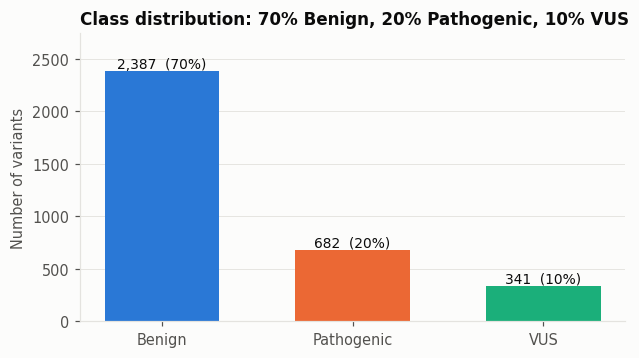

In [4]:
from src.analysis import biomarker_analysis as ba
ba.plot_class_distribution(raw);

The label is imbalanced: 70% Benign, 20% Pathogenic and 10% VUS. Models are trained on the **Pathogenic vs Benign** rows only; the VUS are held back to be reclassified at the end.

## 2. Biomarker analysis
For each numeric feature we compare Pathogenic vs Benign with the **Mann-Whitney U test** (no normality assumption), control the false discovery rate with **Benjamini-Hochberg**, and report the **rank-biserial correlation** (effect size) and the **single-feature ROC AUC**.

In [5]:
results = ba.run(raw)               # runs every test and saves every figure/table
plt.close("all")                    # figures are re-drawn one by one below
num_tests = results["numeric_tests"]
num_tests[["feature", "group", "benign_median", "pathogenic_median",
           "rank_biserial", "univariate_auc", "q_value"]].round(4)

16:33:23 | INFO    | src.analysis.biomarker_analysis | Biomarker analysis: 15/19 numeric features significant at q < 0.05


,feature,group,benign_median,pathogenic_median,rank_biserial,univariate_auc,q_value
0,REVEL_Score,Genomic,0.1830,0.7475,0.6141,0.8071,0.0000
1,PolyPhen2_Score,Genomic,0.2275,0.8850,0.5786,0.7893,0.0000
2,gnomAD_AF,Genomic,0.0022,0.0000,-0.5518,0.7759,0.0000
3,CADD_Phred,Genomic,9.1400,24.8500,0.5009,0.7504,0.0000
4,GERP_RS,Genomic,0.6800,4.3850,0.4446,0.7223,0.0000
5,SIFT_Score,Genomic,0.4930,0.0575,-0.4438,0.7219,0.0000
6,PhyloP_100way,Genomic,1.0600,6.3300,0.4272,0.7136,0.0000
7,HRD_Score,Biomarker,17.2500,48.0000,0.4183,0.7092,0.0000
8,SpliceAI_Score,Genomic,0.0590,0.4140,0.4049,0.7024,0.0000
9,Tumor_Mutational_Burden,Biomarker,6.7200,13.5100,0.2653,0.6327,0.0000


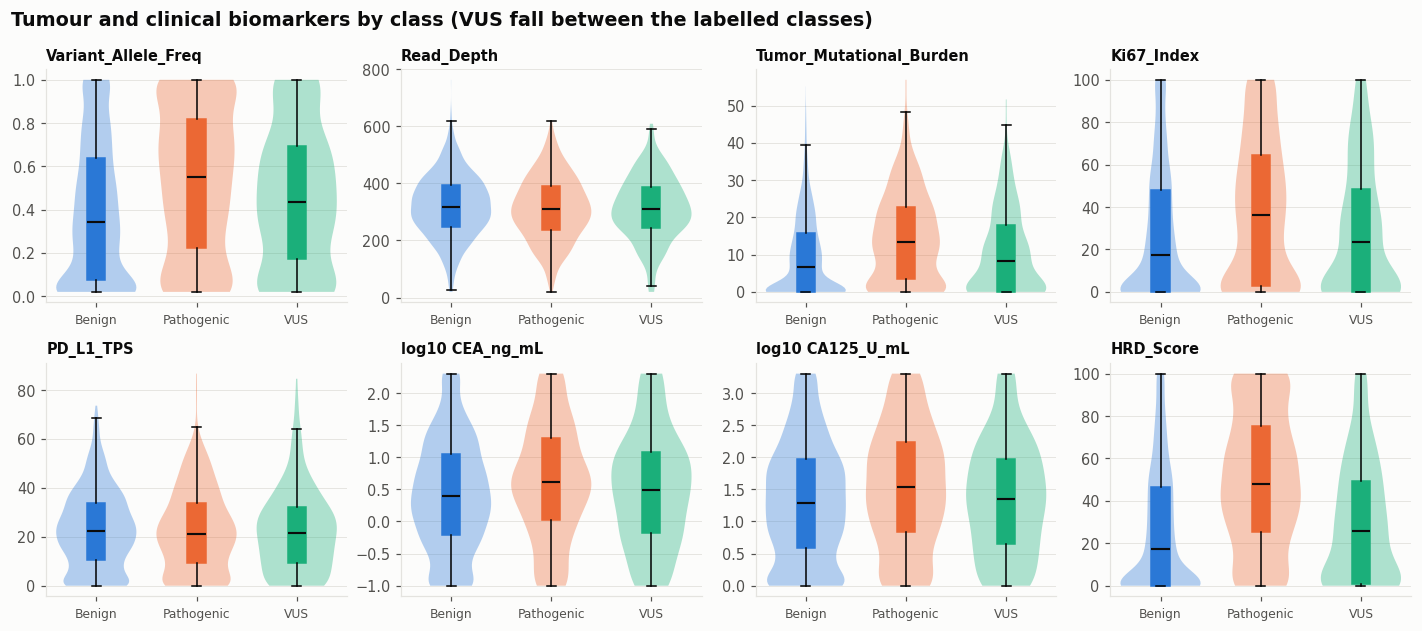

In [6]:
ba.plot_biomarker_distributions(raw);

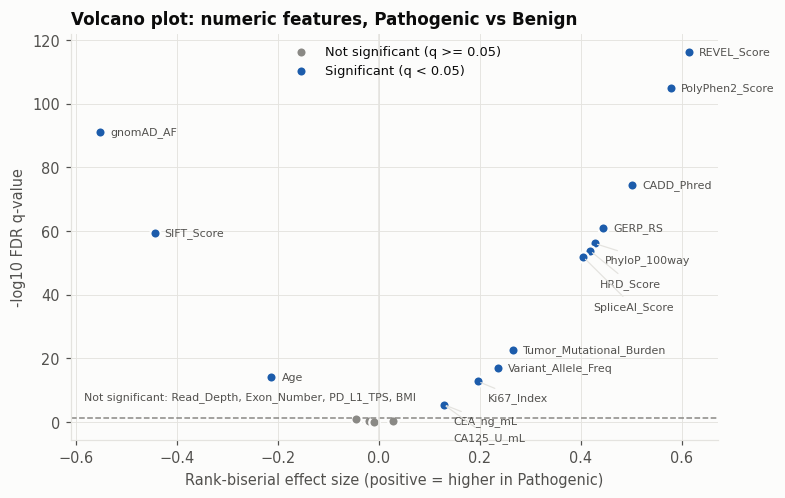

In [7]:
ba.plot_volcano(num_tests);

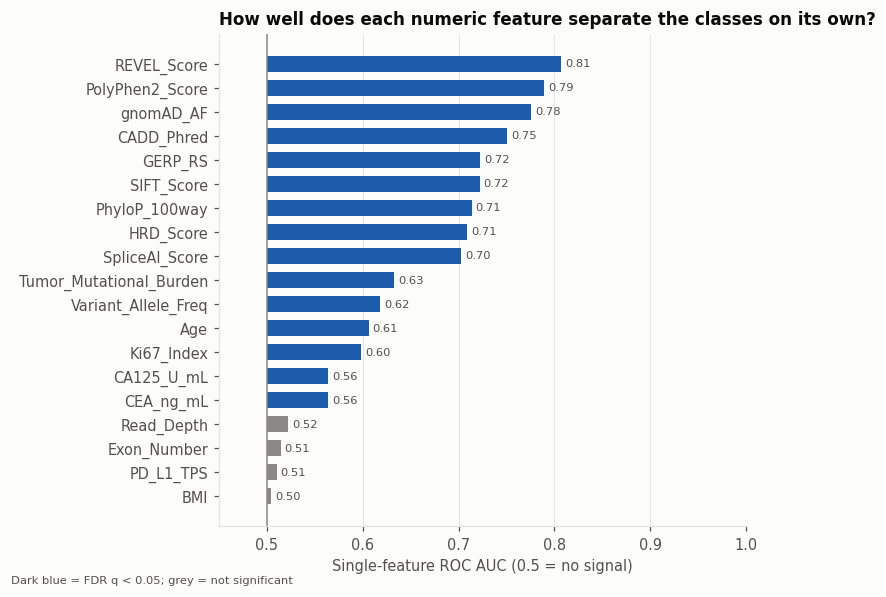

In [8]:
ba.plot_univariate_auc(num_tests);

**Reading the biomarker results**

* HRD score, tumour mutational burden, Ki-67 and variant allele frequency are higher in Pathogenic variants (all FDR q < 0.05).
* CEA and CA125 differ only slightly (small effect sizes).
* PD-L1 TPS and read depth show **no** association; they behave as noise and are expected to be removed during feature selection.
* The VUS medians sit between Benign and Pathogenic, which is what we expect from a mix of both.

## 3. Demographic analysis
Chi-square test of independence with Cramér's V for each categorical demographic variable.

In [9]:
results["demography_tests"].round(4)

,feature,chi2,dof,chi2_p,cramers_v,q_value
0,Family_History_Cancer,414.1708,1,0.0000,0.3956,0.0000
1,Smoking_Status,6.1393,2,0.0464,0.0480,0.1393
2,Alcohol_Use,2.1053,2,0.3490,0.0281,0.6980
3,Ethnicity,1.6158,4,0.8059,0.0249,0.8608
4,Sex,0.1458,1,0.7026,0.0074,0.8608
5,Cancer_Type,1.9150,5,0.8608,0.0270,0.8608


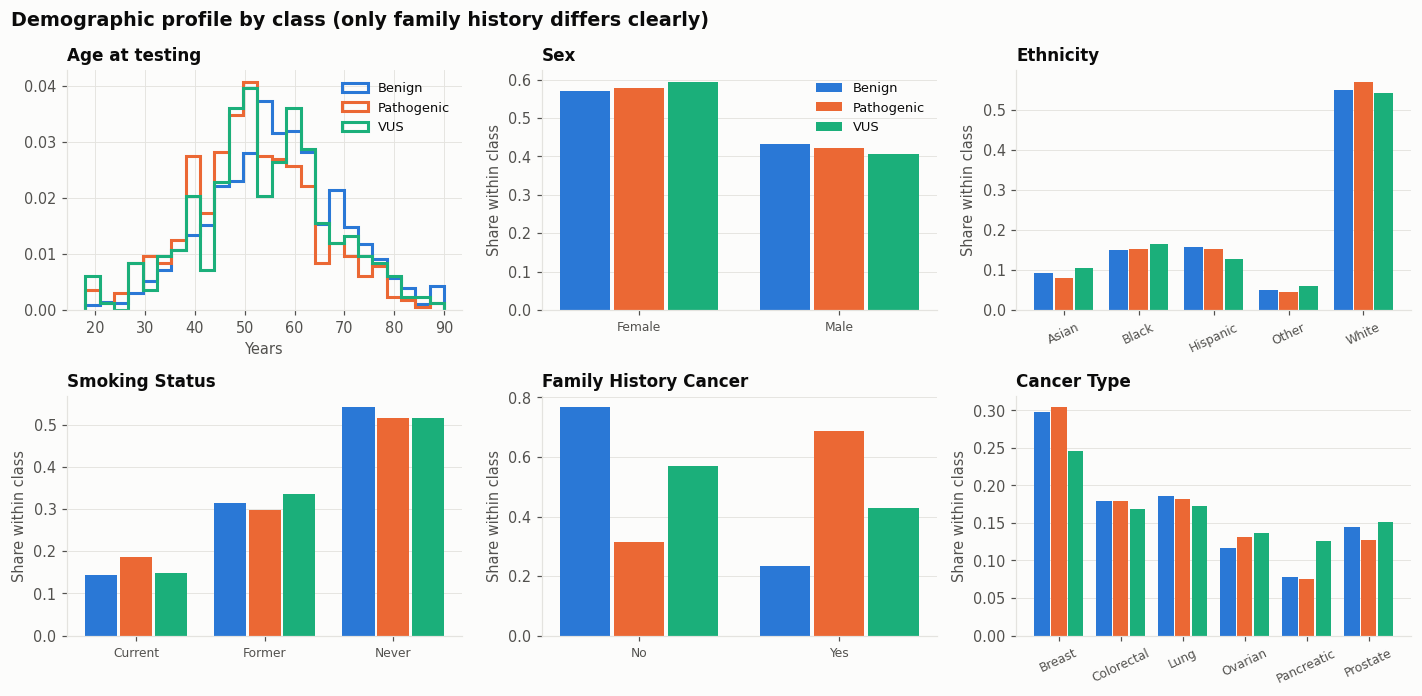

In [10]:
ba.plot_demography(raw);

Only **family history of cancer** is strongly associated with pathogenicity (Cramér's V ≈ 0.4). Sex, ethnicity, smoking, alcohol and cancer type are not, which is reassuring for fairness: the models should not need them.

## 4. Genomic analysis
Variant consequence enrichment (Fisher's exact test, odds ratios), gene-level pathogenic rates with Wilson confidence intervals, in-silico predictor distributions, and population allele frequency against the ACMG BA1 / BS1 / PM2 thresholds.

In [11]:
from src.analysis import genomic_analysis as ga
gres = ga.run(raw)
plt.close("all")
gres["enrichment"][["feature", "level", "n", "pathogenic_rate", "odds_ratio",
                    "or_ci_low", "or_ci_high", "fisher_q"]].round(3)

16:33:27 | INFO    | src.analysis.genomic_analysis | Genomic analysis done: 17 enrichment tests, 7 significant


,feature,level,n,pathogenic_rate,odds_ratio,or_ci_low,or_ci_high,fisher_q
0,Variant_Type,Frameshift,243,0.613,6.891,5.222,9.092,0.000
1,Variant_Type,Missense,1441,0.143,0.347,0.287,0.420,0.000
2,Variant_Type,Nonsense,192,0.672,8.638,6.294,11.857,0.000
3,Variant_Type,Splice_site,194,0.469,3.394,2.520,4.571,0.000
4,Variant_Type,Synonymous,574,0.038,0.106,0.069,0.163,0.000
5,In_Functional_Domain,No,1594,0.065,0.086,0.068,0.108,0.000
6,In_Functional_Domain,Yes,1049,0.450,11.670,9.248,14.727,0.000
7,Gene,APC,242,0.244,1.092,0.802,1.485,0.927
8,Gene,ATM,261,0.222,0.955,0.703,1.298,0.991
9,Gene,BRCA1,258,0.229,0.995,0.733,1.350,1.000


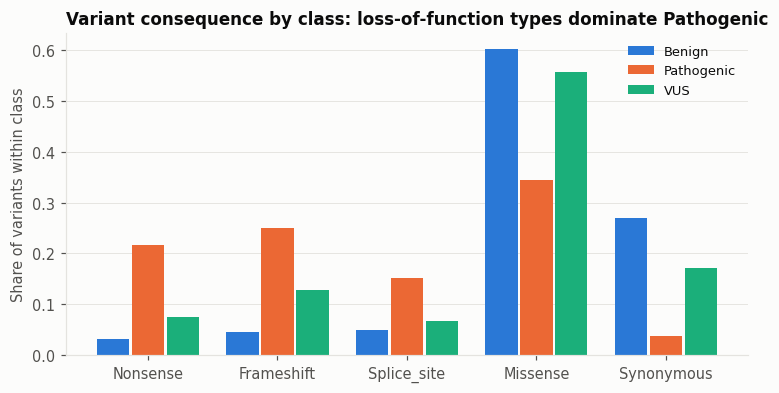

In [12]:
ga.plot_variant_type(raw);

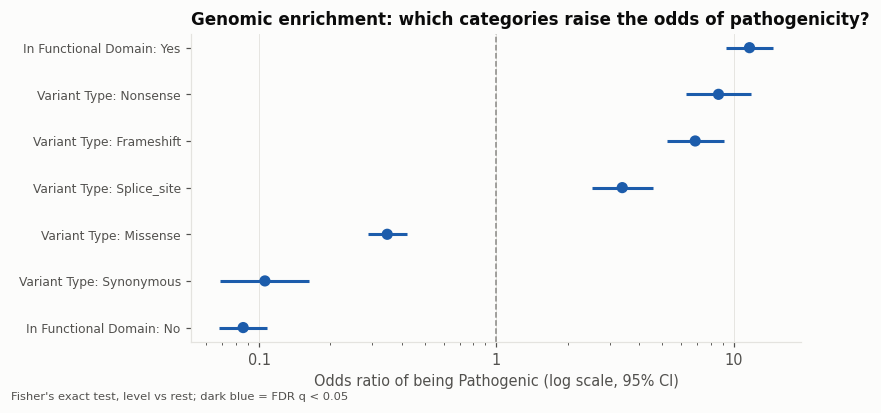

In [13]:
ga.plot_enrichment_forest(gres["enrichment"][gres["enrichment"].feature != "Gene"]);

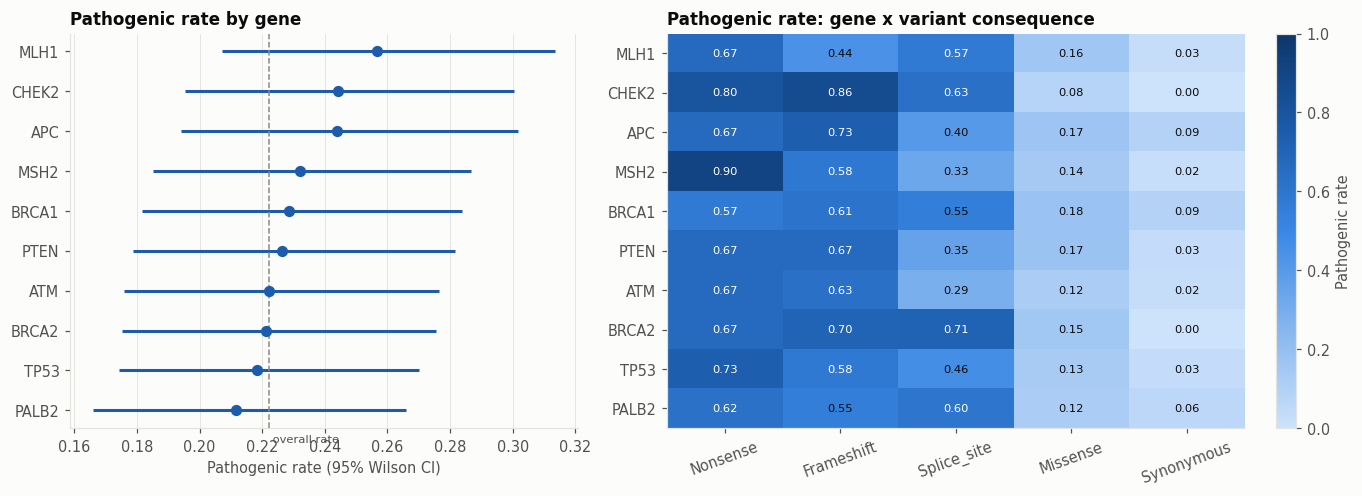

In [14]:
lab, y = ba.labelled(raw)
ga.plot_gene_landscape(lab, y);

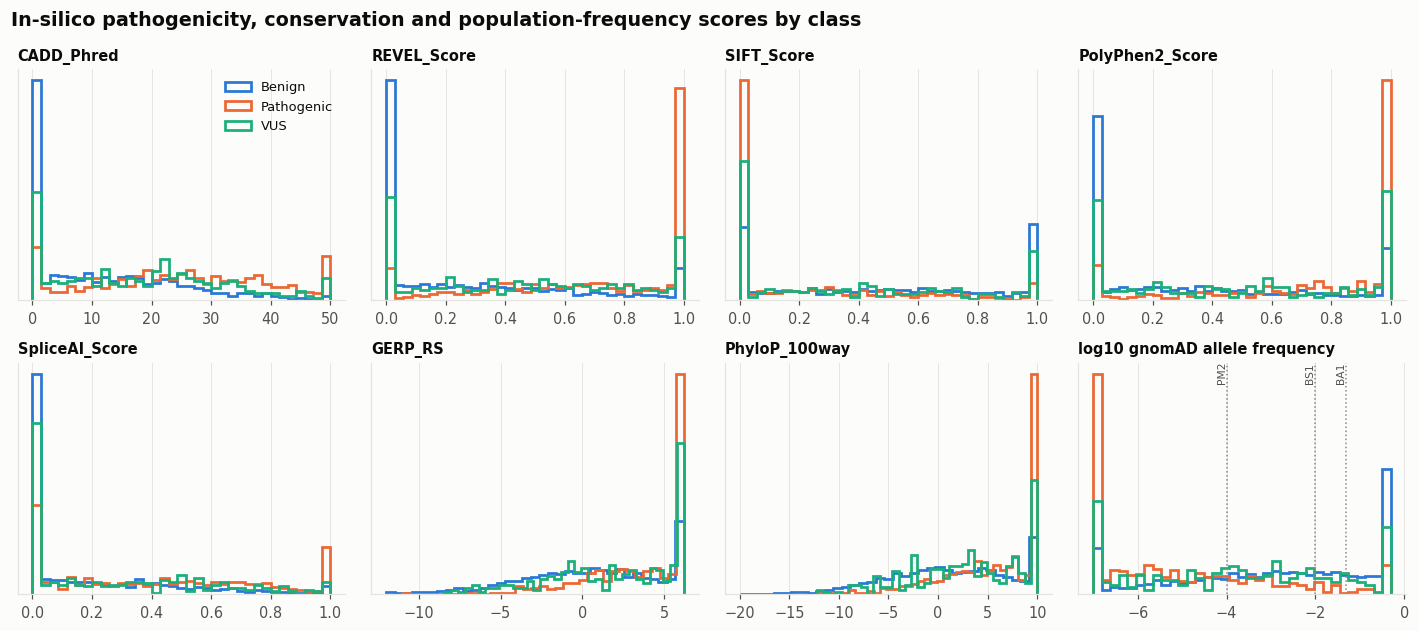

In [15]:
ga.plot_insilico(raw);

,count,mean,std,min,25%,50%,75%,max
Classification,,,,,,,,
Benign,2387.0,1.74,1.25,0.0,1.0,2.0,2.0,7.0
Pathogenic,682.0,3.87,1.40,0.0,3.0,4.0,5.0,7.0
VUS,341.0,2.67,1.40,0.0,2.0,3.0,4.0,7.0


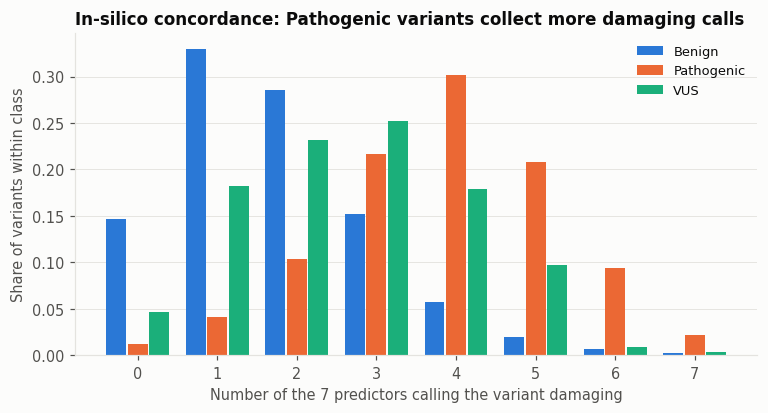

In [16]:
ga.plot_concordance(raw)
gres["concordance"]

**Reading the genomic results**

* Loss-of-function consequences (nonsense, frameshift, splice-site) and variants in a functional domain have much higher odds of being Pathogenic; synonymous and missense variants have lower odds.
* The **gene** alone is not informative in this dataset (all gene rates overlap the overall rate), but gene × consequence shows the expected pattern.
* REVEL, PolyPhen-2, CADD, SIFT, SpliceAI, GERP and PhyloP all separate the classes; Pathogenic variants collect more concordant *damaging* calls.
* Pathogenic variants are rarer in gnomAD (lower allele frequency), matching the ACMG PM2 criterion.

## 5. Where are the VUS?
In every plot above the VUS sit between the two labelled classes. This supports treating them as a mixture that a model trained on confident labels can separate. That is done in notebooks 03 and 05.